# Punto 1 — Programación lineal: Simplex

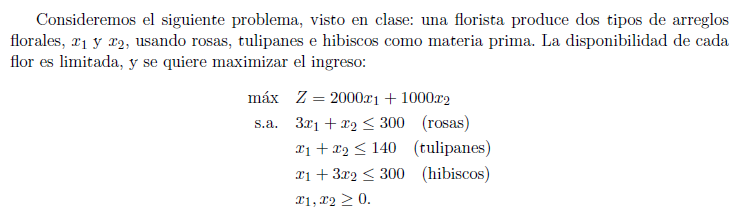

In [5]:
import numpy as np

## Funciones

In [6]:
def forma_estandar(A, b, c):
    """
    Descripción:Construye la matriz y  vector de costos ampliados.
    Parámetros:
        A: matriz coeficiente de restricciones.
        b: vector de disponibilidad.
        c: vector coeficiente de funcion objetivo.
    Retorna:
        A_ampliada: matriz A ampliada, coeficientes de restriccion más identidad.
        c_ampliada: vector de disponibilidad ampliado, el original más ceros.
        m: tamaño de filas de la matriz A.
        n: tamaño de columna de la matriz A.
    """
    m, n = A.shape
    A_ampliada = np.hstack([A, np.eye(m)])
    c_ampliada = np.concatenate([c, np.zeros(m)])
    return A_ampliada, c_ampliada, m, n

def inicializar(m, n):
    """
    Descripción: asignación de índices a variables básicas (B) y no básicas (N).
    Parámetros:
        m: tamaño de filas de la matriz A original.
        n: tamaño de columnas de la matriz A original.
    Retorna:
        B: índices de las variables básicas.
        N: índices de las variables no básicas.
    """
    B = list(range(n, n + m))   
    N = list(range(n))         
    return B, N

def costos_reducidos(A_amp, c_amp, B, N):
    """
    Descripción: calculo de costos reducidos.
    Parámetros:
        A_amp: matriz A ampliada.
        c_amp: vector de coeficiente de la funcion objetivo ampliado.
        B: índices de las variables básicas.
        N: índices de las variable no básicas.
    Retorna:
        c_reducidos: costos reducidos para cada variable no básica.
        A_B_inv: matriz inversa de A_B.
        yT: vector y transpuesto
    """
    
    A_B = A_amp[:, B]    #definición de A_B
    A_B_inv = np.linalg.inv(A_B)     #inversa de A_B

    c_B = c_amp[B]                   #definición de c_B
    cT_B = c_B.T            

    y = cT_B @ A_B_inv  
    yT =  y.T             
    c_reducidos = {j: yT @ A_amp[:, j] - c_amp[j] for j in sorted(N)}   #cálculo de los costos reducidos para las variables no básicas.
    return c_reducidos, A_B_inv, yT

def elegir_variable_entrante(c_reducidos):
    """
    Descripción: elección de la variable entrante a la nueva base que se usará en la siguiente iteración.
    Parámetros:
        c_reducidos: vector de costos reducidos previamente calculados.
    Retorna:
        j_entra: la variable que entra a la nueva base.
    """
    j_entra = min(c_reducidos, key=c_reducidos.get)
    if c_reducidos[j_entra] >= -1e-10:
        return None  # ya es óptimo
    return j_entra

def elegir_saliente_razon_minima(A_B_inv, A_amp, x_B, B, j_entra):
    """
    Descripción: prueba de la razón minima sobre las restricciones y la variable que entra, 
    para identificar cual variable sale de la base que está en uso.
    Parámetros: 
        A_B_inv: matriz inversa de A_B.
        A_amp: matriz A ampliada.
        x_B: vector de variables básicas.
        B: índice variables básicas.
        j_entra: variable que entra a la base.
    Retorna: 
        i_sale: variable que sale de la base
        x_B_actual: solución básica actual (AB^-1 * b).
        d: dirección de cambio (AB^-1 * A_Nj).
    """

    x_B_actual = A_B_inv @ b              
    d = A_B_inv @ A_amp[:, j_entra]

    restric = {}
    for i in range(len(B)):
        if d[i] > 1e-10:                   
            restric[i] = x_B_actual[i] / d[i]

    if not restric:
        return None

    print("sobrantes:", restric.values())
    r_min = min(restric.values())

    iguales = [i for i, r in restric.items() if abs(r - r_min) < 1e-10]
    i_sale = min(iguales, key=lambda i: B[i])   # si tengo costos iguales, que escoja el que tenga menor indice.

    return i_sale


### 1.1. Implementación del método Simplex de forma genérica arrancando de la base de holguras.

In [7]:
def simplex(A, b, c, max_iter=100, verbose=True):
    """
    Descripción: ejecuta el método simplex de optimizacion lineal.
    Parámetros:
        A: matriz de coeficiente de restricciones.
        b: vector de disponibilidad de variables.
        c: vector de coeficientes de la función objetivo.
        max_iter: número de iteraciones.
        verbose: si es True, imprime el progreso de cada iteración.
    """
 
    A_amp, c_amp, m, n = forma_estandar(A, b, c)
    B, N = inicializar(m, n)

    # calculo por iteraciones
    for it in range(max_iter):
        c_reducidos, A_B_inv, yT = costos_reducidos(A_amp, c_amp, B, N)
        print("vector de costos:", c_reducidos.values())
        j_entra = elegir_variable_entrante(c_reducidos)
        
        if j_entra is None:
            x_B = A_B_inv @ b
            x_sol = np.zeros(n + m)
            for idx, val in zip(B, x_B):
                x_sol[idx] = val
            Z = c_amp @ x_sol
            if verbose:
                print(f"Óptimo en la iteración {it}")
            return {
                "x": x_sol[:n], "Z": Z, "y": yT,
                "B": B, "iteraciones": it
            }
        
        i_sale = elegir_saliente_razon_minima(A_B_inv, A_amp, b, B, j_entra)

        if i_sale is None:
            raise ValueError("Problema no acotado")

        if verbose:
            print(f"Iter {it}: entra x{j_entra+1}, sale variable s{i_sale+1}")

        N.remove(j_entra)
        N.append(B[i_sale])
        B[i_sale] = j_entra

    raise ValueError("Se alcanzó el máximo de iteraciones")

### 1.2. Reproducción del óptimo visto en clase: x∗ = (80, 60), Z∗ = 220 000.

In [8]:
A = np.array([
    [3, 1],
    [1, 1],
    [1, 3]
], dtype=float)
b = np.array([300, 140, 300], dtype=float)
c = np.array([2000, 1000], dtype=float)

resultado = simplex(A, b, c)
print("x* =", resultado["x"])
print("Z* =", resultado["Z"])

vector de costos: dict_values([-2000.0, -1000.0])
sobrantes: dict_values([100.0, 140.0, 300.0])
Iter 0: entra x1, sale variable s1
vector de costos: dict_values([-333.33333333333337, 666.6666666666666])
sobrantes: dict_values([300.0, 59.99999999999999, 75.0])
Iter 1: entra x2, sale variable s2
vector de costos: dict_values([500.0, 500.0])
Óptimo en la iteración 2
x* = [80. 60.]
Z* = 220000.0


### 1.3. Agregar un tercer tipo de arreglo floral y resolver el problema extendido con la misma implementación

In [9]:
# el tercer arreglo consumirá 2 rosas, 2 tulipanes y 1 hibisco. Tendrá un precio de $1500
A = np.array([
    [3, 1, 2],
    [1, 1, 2],
    [1, 3, 1]
], dtype=float)
b = np.array([300, 140, 300], dtype=float)
c = np.array([2000, 1000, 1500], dtype=float)

resultado_tercer1500 = simplex(A, b, c)
print("x* =", resultado_tercer1500["x"])
print("Z* =", resultado_tercer1500["Z"])

vector de costos: dict_values([-2000.0, -1000.0, -1500.0])
sobrantes: dict_values([100.0, 140.0, 300.0])
Iter 0: entra x1, sale variable s1
vector de costos: dict_values([-333.33333333333337, -166.66666666666674, 666.6666666666666])
sobrantes: dict_values([300.0, 59.99999999999999, 75.0])
Iter 1: entra x2, sale variable s2
vector de costos: dict_values([500.0, 500.0, 500.0])
Óptimo en la iteración 2
x* = [80. 60.  0.]
Z* = 220000.0


El tercer arreglo floral no resulta rentable, debido a la cantidad de recursos que utiliza y el precio estipulado. El óptimo lo confirma, ignorando la nueva variable. De igual manera se puede confirmar calculando ((y∗)^T)(2,2,0)​−c3​=(500)(2)+(500)(2)+(0)(1)−1500=2000−1500=500. Producir una unidad consume recursos que valen 2000, pero solo genera $1500 en ingreso.

Si conservamos la cantidad de los recursos pero le cambiamos el precio de venta al tercer arreglo por 2500, este resulta más rentable que el segundo, dado el costo de oportunidad de los recursos escasos (rosas y tulipanes), y lo desplaza completamente de la solución óptima. Esto se puede verificar en la siguiente implementación:

In [10]:
# el tercer arreglo consumirá 2 rosas, 2 tulipanes y 1 hibisco. Tendrá un precio de $2500
A = np.array([
    [3, 1, 2],
    [1, 1, 2],
    [1, 3, 1]
], dtype=float)
b = np.array([300, 140, 300], dtype=float)
c = np.array([2000, 1000, 2500], dtype=float)

resultado_tercer2500 = simplex(A, b, c)
print("x* =", resultado_tercer2500["x"])
print("Z* =", resultado_tercer2500["Z"])

vector de costos: dict_values([-2000.0, -1000.0, -2500.0])
sobrantes: dict_values([150.0, 70.0, 300.0])
Iter 0: entra x3, sale variable s2
vector de costos: dict_values([-750.0, 250.0, 1250.0])
sobrantes: dict_values([80.0, 140.0, 460.0])
Iter 1: entra x1, sale variable s1
vector de costos: dict_values([250.0, 375.0000000000001, 874.9999999999999])
Óptimo en la iteración 2
x* = [80.  0. 30.]
Z* = 235000.00000000003


### 1.4. Análisis de sensibilidad sobre el problema inicial

Para este punto se utilizará el método analítico basado en rangos, derivado directamente de las condiciones de optimalidad del método Simplex. El problema original tiene dos tipos de coeficientes que pueden variar: el vector b, que representa la disponibilidad de cada recurso (rosas, tulipanes e hibiscos), y el vector c, que representa el precio de venta de cada arreglo floral (x1,x2). 

El método consiste en usar la matriz inversa de las variables básicas (A_B^-1) ya calculada en la solución óptima, para determinar el rango exacto en el que puede variar cada uno de estos coeficientes sin que cambie la base óptima actual, es decir, sin que cambie cuáles variables conviene producir. Se espera que de esta manera se obtenga información precisa sobre qué tan sensible es la solución óptima a cambios en la disponibilidad de flores y en los precios de venta.

In [11]:
def rango_sensibilidad_b(A, b, c, resultado):
    """
    Descripción: calcula para cada recurso i, el rango de variación de b_i
    que mantiene óptima la base actual.
    Parámetros:
        A, b, c: datos originales del problema.
        resultado: diccionario retornado por simplex(A, b, c).
    Retorna:
        rangos: diccionario {i: (delta_min, delta_max)} por recurso.
    """
    A_amp, c_amp, m, n = forma_estandar(A, b, c)
    B = resultado["B"]
    A_B_inv = np.linalg.inv(A_amp[:, B])
    x_B = A_B_inv @ b

    rangos = {}
    for i in range(m):
        g = A_B_inv[:, i]
        cotas_inf = [-x_B[j] / g[j] for j in range(len(B)) if g[j] > 1e-10]
        cotas_sup = [-x_B[j] / g[j] for j in range(len(B)) if g[j] < -1e-10]
        delta_min = max(cotas_inf) if cotas_inf else -np.inf
        delta_max = min(cotas_sup) if cotas_sup else np.inf
        rangos[i] = (delta_min, delta_max)
    return rangos


def rango_sensibilidad_c(A, b, c, resultado):
    """
    Descripción: calcula para cada variable básica original (x1, x2, ...),
    el rango de variación de su costo c_j que mantiene óptima la base actual.
    Parámetros:
        A, b, c: datos originales del problema.
        resultado: diccionario retornado por simplex(A, b, c).
    Retorna:
        rangos: diccionario {j: (delta_min, delta_max)} por variable básica original.
    """
    A_amp, c_amp, m, n = forma_estandar(A, b, c)
    B = resultado["B"]
    N = sorted(j for j in range(n + m) if j not in B)
    A_B_inv = np.linalg.inv(A_amp[:, B])

    c_reducidos, _, _ = costos_reducidos(A_amp, c_amp, B, N)
    r = np.array([-c_reducidos[j] for j in N])  
    A_N = A_amp[:, N]
    Q = A_B_inv @ A_N  

    rangos = {}
    for k, j_basica in enumerate(B):
        if j_basica >= n:
            continue   # solo nos interesan x1, x2 (no las holguras)
        q = Q[k, :]
        cotas_inf = [r[idx] / q[idx] for idx in range(len(q)) if q[idx] > 1e-10]
        cotas_sup = [r[idx] / q[idx] for idx in range(len(q)) if q[idx] < -1e-10]
        delta_min = max(cotas_inf) if cotas_inf else -np.inf
        delta_max = min(cotas_sup) if cotas_sup else np.inf
        rangos[j_basica] = (delta_min, delta_max)
    return rangos

In [12]:
A = np.array([
    [3, 1],
    [1, 1],
    [1, 3]
], dtype=float)
b = np.array([300, 140, 300], dtype=float)
c = np.array([2000, 1000], dtype=float)

resultado = simplex(A, b, c, verbose=False)

rangos_b = rango_sensibilidad_b(A, b, c, resultado)
rangos_c = rango_sensibilidad_c(A, b, c, resultado)

recursos = ["rosas", "tulipanes", "hibiscos"]
for i, nombre in enumerate(recursos):
    dmin, dmax = rangos_b[i]
    print(f"{nombre}: b{i+1} puede variar en [{b[i]+dmin:.1f}, {b[i]+dmax:.1f}]  (δ ∈ [{dmin:.1f}, {dmax:.1f}])")

for j, nombre in zip([0,1], ["c1 (x1)", "c2 (x2)"]):
    dmin, dmax = rangos_c[j]
    print(f"{nombre}: puede variar en [{c[j]+dmin:.1f}, {c[j]+dmax:.1f}]  (δ ∈ [{dmin:.1f}, {dmax:.1f}])")

vector de costos: dict_values([-2000.0, -1000.0])
sobrantes: dict_values([100.0, 140.0, 300.0])
vector de costos: dict_values([-333.33333333333337, 666.6666666666666])
sobrantes: dict_values([300.0, 59.99999999999999, 75.0])
vector de costos: dict_values([500.0, 500.0])
rosas: b1 puede variar en [260.0, 420.0]  (δ ∈ [-40.0, 120.0])
tulipanes: b2 puede variar en [100.0, 150.0]  (δ ∈ [-40.0, 10.0])
hibiscos: b3 puede variar en [260.0, inf]  (δ ∈ [-40.0, inf])
c1 (x1): puede variar en [1000.0, 3000.0]  (δ ∈ [-1000.0, 1000.0])
c2 (x2): puede variar en [666.7, 2000.0]  (δ ∈ [-333.3, 1000.0])


Los resultados muestran que el hibisco es el único recurso no escaso en la solución óptima (sobran 40 unidades), por lo que su disponibilidad puede aumentar indefinidamente sin afectar la decisión de producción, mientras que una reducción mayor a 40 unidades sí comprometería la base actual.

Por otro lado, las rosas y los tulipanes son recursos escasos (se consumen por completo), y por eso su disponibilidad solo puede moverse dentro de un rango acotado ([260, 420] y [100, 150] respectivamente) antes de que convenga cambiar la combinación de arreglos a producir.

Por último, en cuanto a los precios de venta x1 y x2, tienen un margen razonable de variación (hasta 3000 y 2000 respectivamente en su cota superior) antes de que la solución óptima deje de ser (80,60), lo que indica que la decisión de producción actual es relativamente robusta frente a fluctuaciones moderadas en los precios.